In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
plt.style.use('fivethirtyeight')

In [3]:
end = datetime.now()
start = datetime(end.year-15, end.month, end.day)
stock = 'ETH-USD'
stock_data = yf.download(stock, start=start, end = end)
features = stock_data[['Open', 'High', 'Low', 'Close', 'Volume']]

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


In [5]:
stock_data.head()

Price,Close,High,Low,Open,Volume
Ticker,ETH-USD,ETH-USD,ETH-USD,ETH-USD,ETH-USD
Date,,,,,
2017-11-09,320.884003,329.451996,307.056000,308.644989,893249984
2017-11-10,299.252991,324.717987,294.541992,320.670990,885985984
2017-11-11,314.681000,319.453003,298.191986,298.585999,842300992
2017-11-12,307.907990,319.153015,298.513000,314.690002,1613479936
2017-11-13,316.716003,328.415009,307.024994,307.024994,1041889984


In [7]:
stock_data.tail()

Price,Close,High,Low,Open,Volume
Ticker,ETH-USD,ETH-USD,ETH-USD,ETH-USD,ETH-USD
Date,,,,,
2025-04-23,1796.104248,1829.709961,1746.924072,1757.196533,22904644756
2025-04-24,1769.831665,1801.691406,1724.740723,1795.979492,15207402759
2025-04-25,1786.634521,1826.696045,1740.331909,1770.003662,17459399281
2025-04-26,1821.881104,1839.363037,1781.473877,1786.532959,11926379867
2025-04-27,1808.174561,1852.489990,1794.670654,1821.758911,11489951744


In [9]:
stock_data.describe().T

,,count,mean,std,min,25%,50%,75%,max
Price,Ticker,,,,,,,,
Close,ETH-USD,2727.0,1.532234e+03,1.222821e+03,8.430830e+01,2.856630e+02,1.552479e+03,2.459703e+03,4.812087e+03
High,ETH-USD,2727.0,1.573747e+03,1.255695e+03,8.534274e+01,2.956234e+02,1.584727e+03,2.537444e+03,4.891705e+03
Low,ETH-USD,2727.0,1.485356e+03,1.186617e+03,8.282989e+01,2.785431e+02,1.501797e+03,2.374940e+03,4.718039e+03
Open,ETH-USD,2727.0,1.531847e+03,1.223291e+03,8.427969e+01,2.862050e+02,1.552264e+03,2.458947e+03,4.810071e+03
Volume,ETH-USD,2727.0,1.340342e+10,1.081329e+10,6.217330e+08,5.820363e+09,1.097833e+10,1.808639e+10,9.245355e+10


In [11]:
stock_data.info()


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2727 entries, 2017-11-09 to 2025-04-27
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   (Close, ETH-USD)   2727 non-null   float64
 1   (High, ETH-USD)    2727 non-null   float64
 2   (Low, ETH-USD)     2727 non-null   float64
 3   (Open, ETH-USD)    2727 non-null   float64
 4   (Volume, ETH-USD)  2727 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 127.8 KB


In [13]:
stock_data.columns


MultiIndex([( 'Close', 'ETH-USD'),
            (  'High', 'ETH-USD'),
            (   'Low', 'ETH-USD'),
            (  'Open', 'ETH-USD'),
            ('Volume', 'ETH-USD')],
           names=['Price', 'Ticker'])

In [15]:
#Close price data
closing_price = stock_data[['Close']]

In [17]:
closing_price['Close']

Ticker,ETH-USD
Date,
2017-11-09,320.884003
2017-11-10,299.252991
2017-11-11,314.681000
2017-11-12,307.907990
2017-11-13,316.716003
...,...
2025-04-23,1796.104248
2025-04-24,1769.831665
2025-04-25,1786.634521


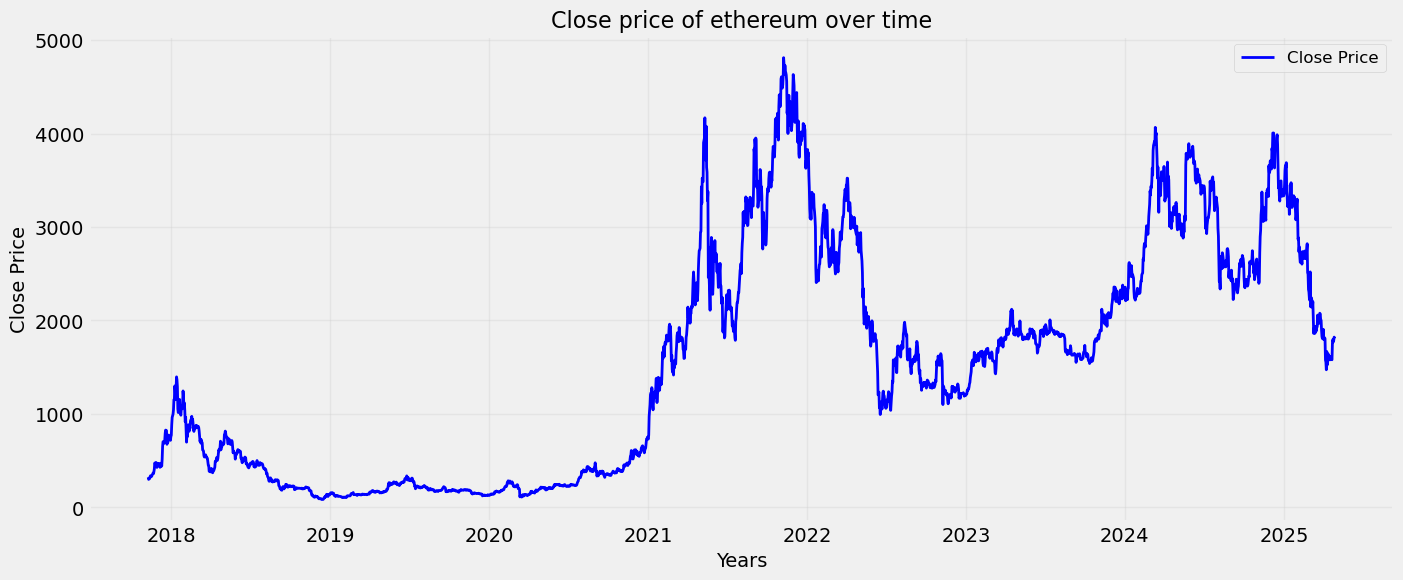

In [19]:
#Plot closing price with enchacement
plt.figure(figsize = (15, 6))
plt.plot(closing_price.index, closing_price['Close'], label = 'Close Price', color = 'blue', linewidth =2)
plt.title("Close price of ethereum over time", fontsize = 16)
plt.xlabel("Years", fontsize = 14)
plt.ylabel('Close Price', fontsize = 14)
plt.grid(alpha = 0.3)
plt.legend(fontsize = 12)
plt.show()

In [21]:
# Moving Average
temp_data = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
# moving average for 5 day -> null null null null 30.0 40.0
print(sum(temp_data[1:6])/5)

40.0


In [23]:
df1 = pd.DataFrame(temp_data)


In [25]:
df1.rolling(5).mean()

,0
0,NaN
1,NaN
2,NaN
3,NaN
4,30.0
5,40.0
6,50.0
7,60.0
8,70.0
9,80.0


In [27]:
for i in range(2014, 2024):
    print(i, list(stock_data.index.year).count(i))

2014 0
2015 0
2016 0
2017 53
2018 365
2019 365
2020 366
2021 365
2022 365
2023 365


In [29]:
closing_price['MA_365'] = closing_price['Close'].rolling(window = 365).mean()
closing_price['MA_100'] = closing_price['Close'].rolling(window = 100).mean()

/var/folders/fk/8t87f4t979d3z85yq371xrtr0000gn/T/ipykernel_95201/194502310.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  closing_price['MA_365'] = closing_price['Close'].rolling(window = 365).mean()
/var/folders/fk/8t87f4t979d3z85yq371xrtr0000gn/T/ipykernel_95201/194502310.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  closing_price['MA_100'] = closing_price['Close'].rolling(window = 100).mean()


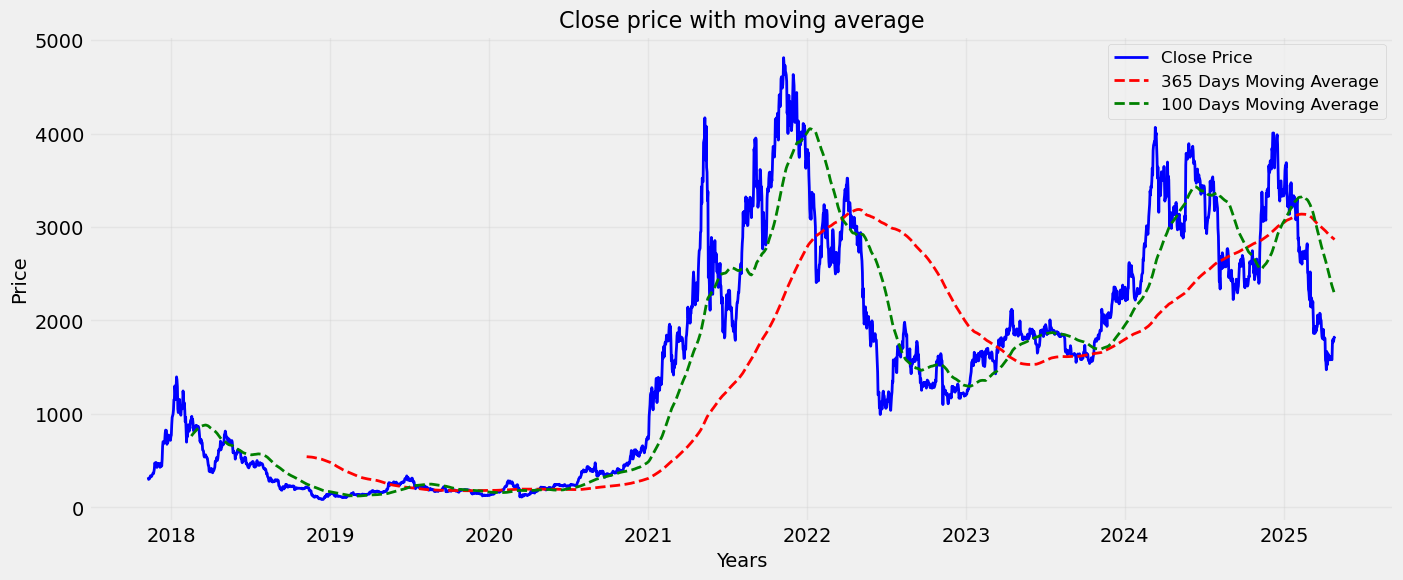

In [31]:
#Plot closing price with enchacement
plt.figure(figsize = (15, 6))
plt.plot(closing_price.index, closing_price['Close'], label = 'Close Price', color = 'blue', linewidth =2)
plt.plot(closing_price.index, closing_price['MA_365'], label = '365 Days Moving Average', color = 'red', linestyle ="--", linewidth =2)
plt.plot(closing_price.index, closing_price['MA_100'], label = '100 Days Moving Average', color = 'green',linestyle ="--", linewidth =2)

plt.title("Close price with moving average", fontsize = 16)
plt.xlabel("Years", fontsize = 14)
plt.ylabel('Price', fontsize = 14)
plt.grid(alpha = 0.3)
plt.legend(fontsize = 12)
plt.show()

In [33]:
# LSTM-> Long short term memory
# scale the data
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(closing_price[['Close']].dropna())

In [35]:
len(scaled_data)

2727

In [37]:
from keras.models import Sequential
from keras.layers import Dense, LSTM

In [39]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [41]:
# Prepare data for lstm
x_data = []
y_data = []
base_days =100
for i in range(base_days, len(scaled_data)):
    x_data.append(scaled_data[i-base_days: i])
    y_data.append(scaled_data[i])
x_data = np.array(x_data)
y_data = np.array(y_data)

In [43]:
# Split into train and test sets
train_size = int(len(x_data) * 0.9)
x_train , y_train = x_data[:train_size], y_data[:train_size]
x_test, y_test = x_data[train_size:], y_data[train_size:]

In [45]:
model = Sequential([
    LSTM(128, return_sequences = True, input_shape = (x_train.shape[1], 1)),
    LSTM(64, return_sequences = False),
    Dense(25),
    Dense(1)
])

model.compile(optimizer = "adam", loss = "mean_squared_error")
model.summary()

/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100, 128)       │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,625 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 117,619 (459.45 KB)

 Trainable params: 117,619 (459.45 KB)

 Non-trainable params: 0 (0.00 B)

In [47]:
model.fit(x_train, y_train, batch_size = 5, epochs = 10)

Epoch 1/10
473/473 ━━━━━━━━━━━━━━━━━━━━ 22s 44ms/step - loss: 0.0058
Epoch 2/10
473/473 ━━━━━━━━━━━━━━━━━━━━ 23s 48ms/step - loss: 9.3198e-04
Epoch 3/10
473/473 ━━━━━━━━━━━━━━━━━━━━ 20s 42ms/step - loss: 6.3184e-04
Epoch 4/10
473/473 ━━━━━━━━━━━━━━━━━━━━ 21s 44ms/step - loss: 5.8600e-04
Epoch 5/10
473/473 ━━━━━━━━━━━━━━━━━━━━ 18s 39ms/step - loss: 4.9727e-04
Epoch 6/10
473/473 ━━━━━━━━━━━━━━━━━━━━ 18s 38ms/step - loss: 4.0019e-04
Epoch 7/10
473/473 ━━━━━━━━━━━━━━━━━━━━ 21s 43ms/step - loss: 4.9688e-04
Epoch 8/10
473/473 ━━━━━━━━━━━━━━━━━━━━ 19s 40ms/step - loss: 4.7450e-04
Epoch 9/10
473/473 ━━━━━━━━━━━━━━━━━━━━ 18s 38ms/step - loss: 4.8081e-04
Epoch 10/10
473/473 ━━━━━━━━━━━━━━━━━━━━ 21s 44ms/step - loss: 5.6121e-04


In [49]:
predictions = model.predict(x_test)
inv_predictions = scaler.inverse_transform(predictions)
inv_y_test = scaler.inverse_transform(y_test)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


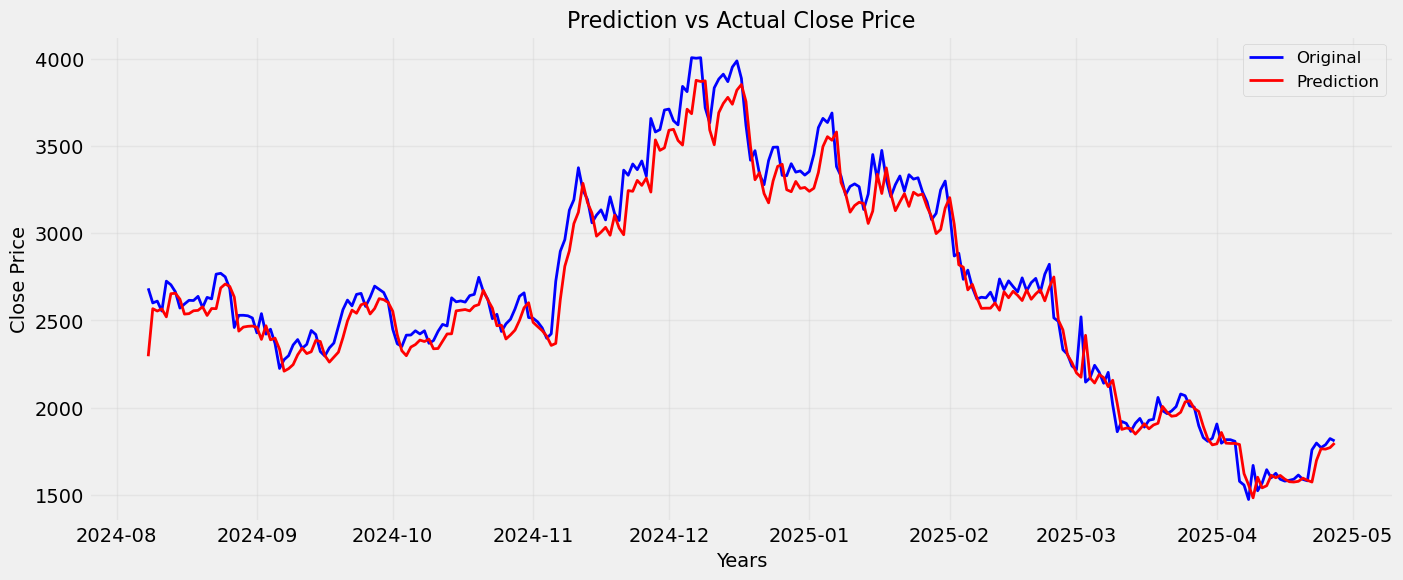

In [51]:
plotting_data = pd.DataFrame(
    {
        'Original': inv_y_test.flatten(), 
        'Prediction': inv_predictions.flatten(),
    }, index = closing_price.index[train_size + base_days:]
)

plt.figure(figsize = (15, 6))
plt.plot(plotting_data.index, plotting_data['Original'], label = 'Original', color = 'blue', linewidth =2)
plt.plot(plotting_data.index, plotting_data['Prediction'], label = 'Prediction', color = 'red',  linewidth =2)

plt.title("Prediction vs Actual Close Price", fontsize = 16)
plt.xlabel("Years", fontsize = 14)
plt.ylabel('Close Price', fontsize = 14)
plt.grid(alpha = 0.3)
plt.legend(fontsize = 12)
plt.show()

In [53]:
# Predict future days
last_100  = scaled_data[-100:].reshape(1, -1, 1)
future_predictions=[]
for _ in range(10):
    next_days = model.predict(last_100)
    future_predictions.append(scaler.inverse_transform(next_days))
    last_100 = np.append(last_100[:, 1:, :], next_days.reshape(1, 1, -1), axis = 1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


In [55]:
future_predictions

[array([[1791.4459]], dtype=float32),
 array([[1776.24]], dtype=float32),
 array([[1759.6967]], dtype=float32),
 array([[1742.5038]], dtype=float32),
 array([[1725.2262]], dtype=float32),
 array([[1708.2778]], dtype=float32),
 array([[1691.9408]], dtype=float32),
 array([[1676.3888]], dtype=float32),
 array([[1661.7109]], dtype=float32),
 array([[1647.9337]], dtype=float32)]

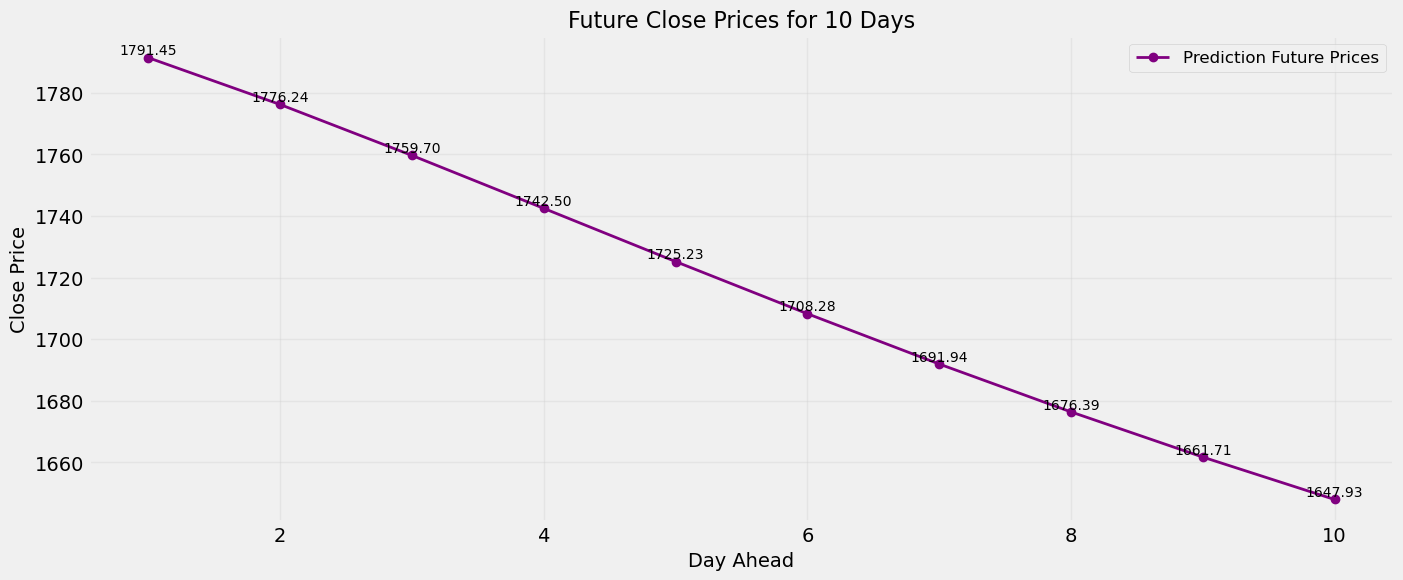

In [57]:
future_predictions = np.array(future_predictions).flatten()

plt.figure(figsize = (15, 6))
plt.plot(range(1, 11), future_predictions, marker="o" ,label = 'Prediction Future Prices', color = 'purple', linewidth =2)

for i, val in enumerate(future_predictions):
    plt.text(i+1,val,  f'{val:.2f}', fontsize = 10, ha = 'center', va = 'bottom', color='black')

plt.title("Future Close Prices for 10 Days", fontsize = 16)
plt.xlabel("Day Ahead", fontsize = 14)
plt.ylabel('Close Price', fontsize = 14)
plt.grid(alpha = 0.3)
plt.legend(fontsize = 12)
plt.show()

In [59]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
mse = mean_squared_error(inv_y_test, inv_predictions)
mae = mean_absolute_error(inv_y_test, inv_predictions)

r2 = r2_score(inv_y_test, inv_predictions)
print("MSE Error:",mse)
print("MAE Error:",mae)
print("Accuracy:",r2*100)


MSE Error: 14684.578722651297
MAE Error: 90.91746793681678
Accuracy: 96.15075841203735


In [61]:
model.save("ETH.keras")

In [63]:
model.save('/Users/aryanbansal/Desktop/BTC_jupyter/ETH.keras')